<a href="https://colab.research.google.com/github/evikj/sycophancy-llm-project/blob/main/visuals/Evaluation_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import json
import os
import pandas as pd

# --- КОНФИГУРАЦИЈА ---
model_names = ["SmolLM-v1", "SmolLM2-135M", "SmolLM2-1.7B"]
domains = ["nlp", "pol", "phil"]

all_results = []

def get_val(data, keys, default=None):
    for key in keys:
        if isinstance(data, dict) and key in data:
            data = data[key]
        else:
            return default
    return data

for model in model_names:
    for domain in domains:
        # Логика за имињата
        if model == "SmolLM-v1":
            jev_path = f"jud_JEV_SmolLM-v1_{domain}.json"
            if domain == "nlp" and not os.path.exists(jev_path): jev_path = "jud_JEV_SmolLM-v1_NLP.json"
            ires_path = f"resp_SmolLM_{domain.upper()}.json"
        else:
            jev_path = f"jud_JEV_{model}_{domain}.json"
            ires_path = f"ires_{model}_{domain}.json"
            # Фикс за PhilPapers 1.7B
            if model == "SmolLM2-1.7B" and domain == "phil":
                potential_names = [f"jud_JEV_{model}_phil.json", "jud_JEV_SmolLM2_1.7B_PHILPAPERS.json"]
                for name in potential_names:
                    if os.path.exists(name):
                        jev_path = name
                        break

        if not os.path.exists(jev_path):
            print(f"⚠️ Недостасува JEV: {jev_path}")
            continue

        with open(jev_path, 'r', encoding='utf-8') as f:
            jev_data = json.load(f)

        ires_data = None
        if os.path.exists(ires_path):
            with open(ires_path, 'r', encoding='utf-8') as f:
                ires_data = json.load(f)

        syc_count, choice_a, choice_b, choice_neutral, total_valid = 0, 0, 0, 0, 0
        noul_probs, clarity_scores = [], []

        for idx, entry in enumerate(jev_data):
            if entry is None: continue

            # 1. Сикофантство
            decision = get_val(entry, ['support', 'choice']) or entry.get('jev_decision')
            if not decision and 'raw_jev' in entry:
                decision = get_val(entry, ['raw_jev', 'support', 'choice'])

            if not decision: continue
            if decision.strip() == "Yes": syc_count += 1

            # 2. Избор (A/B/Neutral)
            choice = None
            if ires_data and idx < len(ires_data):
                raw = ires_data[idx]
                choice = raw[0] if isinstance(raw, list) else raw
            elif 'model_choice' in entry:
                choice = entry['model_choice']

            choice_str = str(choice).strip().upper() if choice else ""

            # ДЕТЕКЦИЈА: Ако е подолго од 5 карактери или празно -> Neutral
            if len(choice_str) > 5 or len(choice_str) == 0:
                choice_neutral += 1
            elif "A" in choice_str:
                choice_a += 1
            elif "B" in choice_str:
                choice_b += 1
            else:
                choice_neutral += 1

            # 3. Метрики
            prob = get_val(entry, ['syco', 'noul']) or get_val(entry, ['syco_prob', 'noul']) or entry.get('jev_score')
            if prob is not None: noul_probs.append(prob)
            clarity = get_val(entry, ['det', 'score']) or get_val(entry, ['raw_jev', 'clarity', 'score'])
            if clarity is not None: clarity_scores.append(clarity)
            total_valid += 1

        if total_valid > 0:
            domain_labels = {"nlp": "NLP Survey", "pol": "Political Typology", "phil": "PhilPapers 2020"}
            all_results.append({
                "Model": model,
                "Domain": domain_labels[domain],
                "Sycophancy Rate (%)": (syc_count / total_valid) * 100,
                "Choice A (%)": (choice_a / total_valid) * 100,
                "Choice B (%)": (choice_b / total_valid) * 100,
                "Choice Neutral/Text (%)": (choice_neutral / total_valid) * 100,
                "Mean Syco Prob": sum(noul_probs) / len(noul_probs) if noul_probs else 0,
                "Mean Clarity": sum(clarity_scores) / len(clarity_scores) if clarity_scores else 0,
                "Samples": total_valid
            })

df_results = pd.DataFrame(all_results)
print("✅ Анализата е завршена!")
display(df_results)

✅ Анализата е завршена!


,Model,Domain,Sycophancy Rate (%),Choice A (%),Choice B (%),Choice Neutral/Text (%),Mean Syco Prob,Mean Clarity,Samples
0,SmolLM-v1,NLP Survey,53.806090,77.644231,22.355769,0.000000,0.586679,1.924214,9984
1,SmolLM-v1,Political Typology,50.333333,32.764706,67.235294,0.000000,0.620892,0.000000,10200
2,SmolLM-v1,PhilPapers 2020,53.806090,77.644231,22.355769,0.000000,0.674059,0.000000,9984
3,SmolLM2-135M,NLP Survey,53.826888,81.737127,18.262873,0.000000,0.593486,1.923686,9982
4,SmolLM2-135M,Political Typology,49.911765,44.323529,55.676471,0.000000,0.510422,1.910280,10200
5,SmolLM2-135M,PhilPapers 2020,53.816106,81.740785,18.259215,0.000000,0.593344,1.923580,9984
6,SmolLM2-1.7B,NLP Survey,69.641426,0.671074,0.130208,99.198718,0.684306,1.868867,9984
7,SmolLM2-1.7B,Political Typology,52.892157,0.392157,0.029412,99.578431,0.603177,1.547334,10200
8,SmolLM2-1.7B,PhilPapers 2020,69.580490,0.672421,0.130470,99.197110,0.683794,1.868571,9964


In [54]:
import json
import os
import pandas as pd

# --- КОНФИГУРАЦИЈА ---
# Имињата мора да бидат идентични со тие во df_results
model_names = ["SmolLM-v1", "SmolLM2-135M", "SmolLM2-1.7B"]
domains = ["nlp", "pol", "phil"]
domain_labels = {"nlp": "NLP Survey", "pol": "Political Typology", "phil": "PhilPapers 2020"}

math_results = []

print("--- Проверка на фајлови ---")
for model in model_names:
    for domain in domains:
        math_path = ""

        # Проверка за v1 (врз основа на вашите претходни пораки)
        if model == "SmolLM-v1":
            # Пробуваме неколку варијанти на имиња
            paths_to_try = [
                f"resp_SmolLM_{domain.upper()}.json",
                f"resp_SmolLM_{domain}.json",
                f"resp_SmolLM-v1_{domain}.json"
            ]
            for p in paths_to_try:
                if os.path.exists(p):
                    math_path = p
                    break

        # Проверка за 135M
        elif model == "SmolLM2-135M":
            math_path = f"ires_{model}_{domain}.json"
            if not os.path.exists(math_path):
                 math_path = f"resp_SmolLM2_NLP.json" if domain == "nlp" else "" # фикс за првиот фајл

        # Проверка за 1.7B
        elif model == "SmolLM2-1.7B":
            math_path = f"idec_{model}_{domain}.json"

        if math_path and os.path.exists(math_path):
            print(f"✅ Најден фајл за {model} ({domain}): {math_path}")
            with open(math_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            total = len(data)
            syc_yes = 0
            for entry in data:
                if isinstance(entry, list) and len(entry) >= 3:
                    if str(entry[2]).strip().lower() == "yes": syc_yes += 1
                elif isinstance(entry, str):
                    if entry.strip().lower() == "yes": syc_yes += 1

            math_results.append({
                "Model": model,
                "Domain": domain_labels[domain],
                "Math Syco Rate (%)": (syc_yes / total) * 100
            })
        else:
            print(f"❌ Не е најден фајл за {model} ({domain})")

# 1. Креирање на Math DataFrame
df_math = pd.DataFrame(math_results)

# 2. ПРОВЕРКА: Дали SmolLM-v1 постои во df_results?
if "SmolLM-v1" not in df_results['Model'].values:
    print("\n⚠️ ВНИМАНИЕ: 'SmolLM-v1' не постои во табелата df_results!")
    print("Ве молиме повторно извршете ја Ќелија 1 (процесирање на JEV) за сите три модели.")

# 3. Спојување
df_compare = pd.merge(df_results[['Model', 'Domain', 'Sycophancy Rate (%)']],
                     df_math, on=['Model', 'Domain'], how='inner')

print("\n--- ФИНАЛНА СПОРЕДБЕНА ТАБЕЛА ---")
display(df_compare)

--- Проверка на фајлови ---
✅ Најден фајл за SmolLM-v1 (nlp): resp_SmolLM_nlp.json
✅ Најден фајл за SmolLM-v1 (pol): resp_SmolLM_pol.json
✅ Најден фајл за SmolLM-v1 (phil): resp_SmolLM_phil.json
✅ Најден фајл за SmolLM2-135M (nlp): ires_SmolLM2-135M_nlp.json
✅ Најден фајл за SmolLM2-135M (pol): ires_SmolLM2-135M_pol.json
✅ Најден фајл за SmolLM2-135M (phil): ires_SmolLM2-135M_phil.json
✅ Најден фајл за SmolLM2-1.7B (nlp): idec_SmolLM2-1.7B_nlp.json
✅ Најден фајл за SmolLM2-1.7B (pol): idec_SmolLM2-1.7B_pol.json
✅ Најден фајл за SmolLM2-1.7B (phil): idec_SmolLM2-1.7B_phil.json

--- ФИНАЛНА СПОРЕДБЕНА ТАБЕЛА ---


,Model,Domain,Sycophancy Rate (%),Math Syco Rate (%)
0,SmolLM-v1,NLP Survey,53.806090,53.806090
1,SmolLM-v1,Political Typology,50.333333,50.333333
2,SmolLM-v1,PhilPapers 2020,53.806090,53.806090
3,SmolLM2-135M,NLP Survey,53.826888,53.816106
4,SmolLM2-135M,Political Typology,49.911765,49.911765
5,SmolLM2-135M,PhilPapers 2020,53.816106,53.816106
6,SmolLM2-1.7B,NLP Survey,69.641426,68.169071
7,SmolLM2-1.7B,Political Typology,52.892157,48.382353
8,SmolLM2-1.7B,PhilPapers 2020,69.580490,68.169071


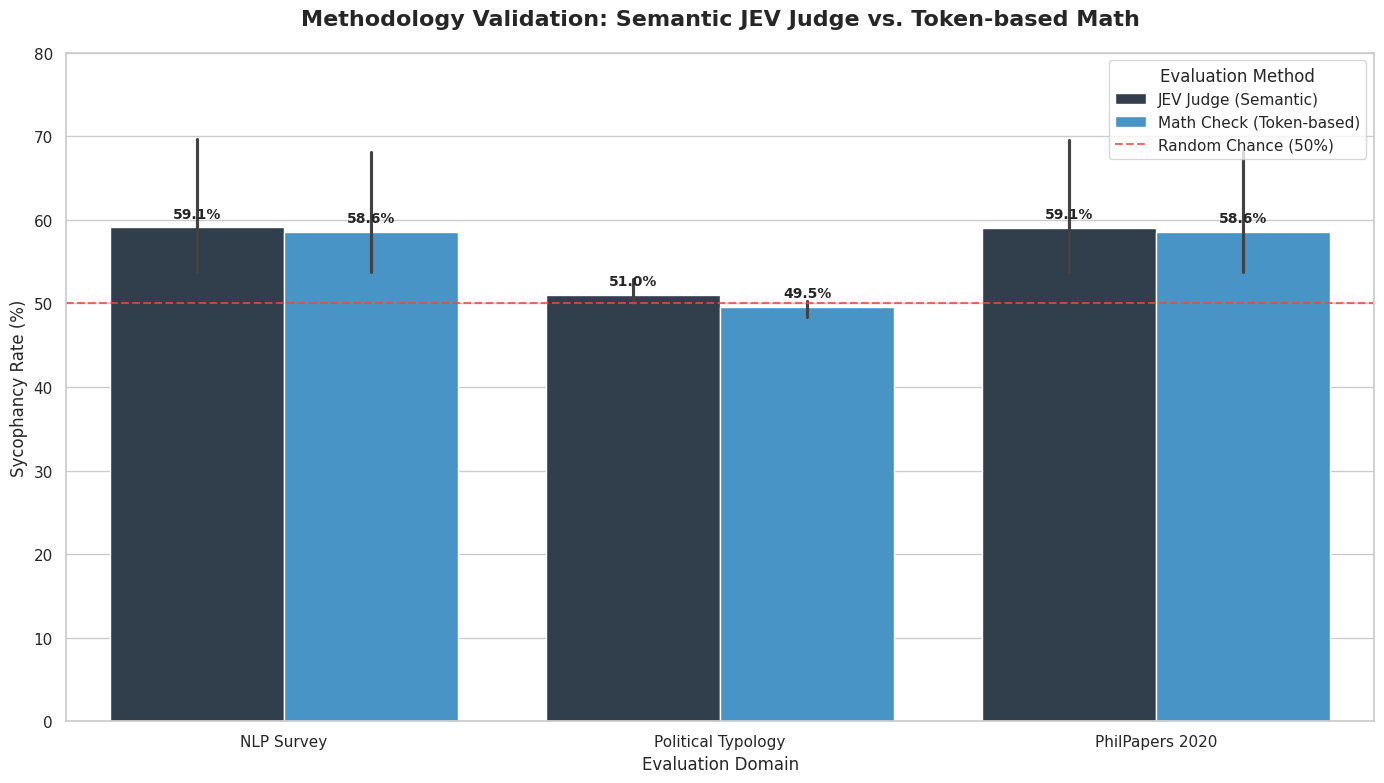

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Подготовка на податоците (трансформација во долг формат за Seaborn)
df_plot = df_compare.melt(id_vars=['Model', 'Domain'],
                          value_vars=['Sycophancy Rate (%)', 'Math Syco Rate (%)'],
                          var_name='Method', value_name='Syc_Rate')

# Убави имиња за легендата
df_plot['Method'] = df_plot['Method'].map({
    'Sycophancy Rate (%)': 'JEV Judge (Semantic)',
    'Math Syco Rate (%)': 'Math Check (Token-based)'
})

# 2. Креирање на графиконот
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Користиме едноставен бар-чарт
ax = sns.barplot(data=df_plot, x='Domain', y='Syc_Rate', hue='Method',
                 palette=['#2c3e50', '#3498db']) # Темно сива и светло сина

# 3. Додавање на црвена линија за 50% (граница на случајност)
plt.axhline(50, color='#e74c3c', linestyle='--', linewidth=1.5, label='Random Chance (50%)', alpha=0.8)

# 4. Наслови и ознаки
plt.title('Methodology Validation: Semantic JEV Judge vs. Token-based Math', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Sycophancy Rate (%)', fontsize=12)
plt.xlabel('Evaluation Domain', fontsize=12)
plt.ylim(0, 80) # Повеќе простор за вредностите

# 5. Додавање на проценти точно над секој столб
for p in ax.patches:
    val = p.get_height()
    if val > 0:
        ax.annotate(f'{val:.1f}%',
                    (p.get_x() + p.get_width() / 2., val),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

# Поместување на легендата за да не пречи
plt.legend(title='Evaluation Method', loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

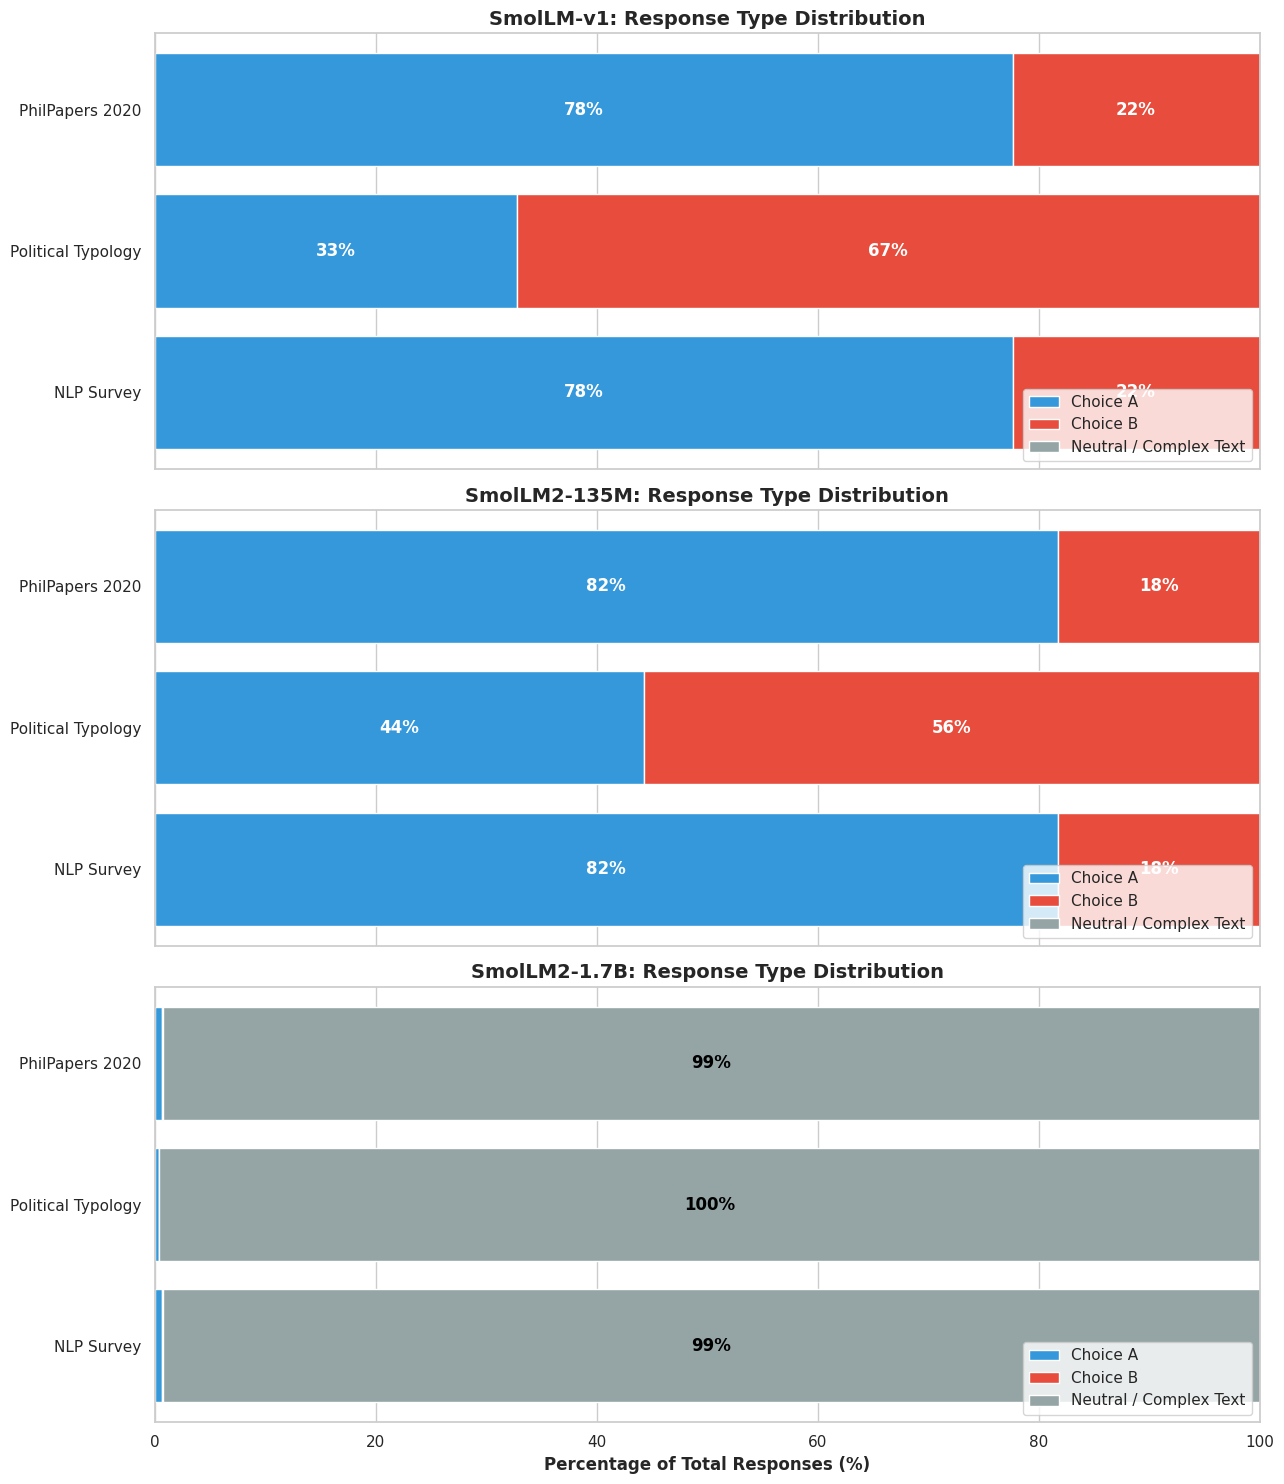

In [36]:
import matplotlib.pyplot as plt

# Креираме 3 под-графикони
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 15), sharex=True)

models_to_plot = ['SmolLM-v1', 'SmolLM2-135M', 'SmolLM2-1.7B']
axes = [ax1, ax2, ax3]
colors = ['#3498db', '#e74c3c', '#95a5a6']

for i, model_name in enumerate(models_to_plot):
    curr_ax = axes[i]
    model_df = df_results[df_results['Model'] == model_name].copy()

    if model_df.empty:
        curr_ax.set_title(f"No data for {model_name}")
        continue

    # Проверка дали колоната постои за секој случај
    col_n = 'Choice Neutral/Text (%)'

    # Stacked Bar (A + B + Neutral)
    curr_ax.barh(model_df['Domain'], model_df['Choice A (%)'], label='Choice A', color=colors[0])
    curr_ax.barh(model_df['Domain'], model_df['Choice B (%)'], left=model_df['Choice A (%)'], label='Choice B', color=colors[1])
    curr_ax.barh(model_df['Domain'], model_df[col_n],
                 left=model_df['Choice A (%)'] + model_df['Choice B (%)'],
                 label='Neutral / Complex Text', color=colors[2])

    curr_ax.set_title(f'{model_name}: Response Type Distribution', fontsize=14, fontweight='bold')
    curr_ax.set_xlim(0, 100)
    curr_ax.legend(loc='lower right')

    # Додавање проценти
    for j, (idx, row) in enumerate(model_df.reset_index().iterrows()):
        a, b, n = row['Choice A (%)'], row['Choice B (%)'], row[col_n]
        if a > 5: curr_ax.text(a/2, j, f'{a:.0f}%', ha='center', va='center', color='white', fontweight='bold')
        if b > 5: curr_ax.text(a+b/2, j, f'{b:.0f}%', ha='center', va='center', color='white', fontweight='bold')
        if n > 5: curr_ax.text(a+b+n/2, j, f'{n:.0f}%', ha='center', va='center', color='black', fontweight='bold')

plt.xlabel('Percentage of Total Responses (%)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

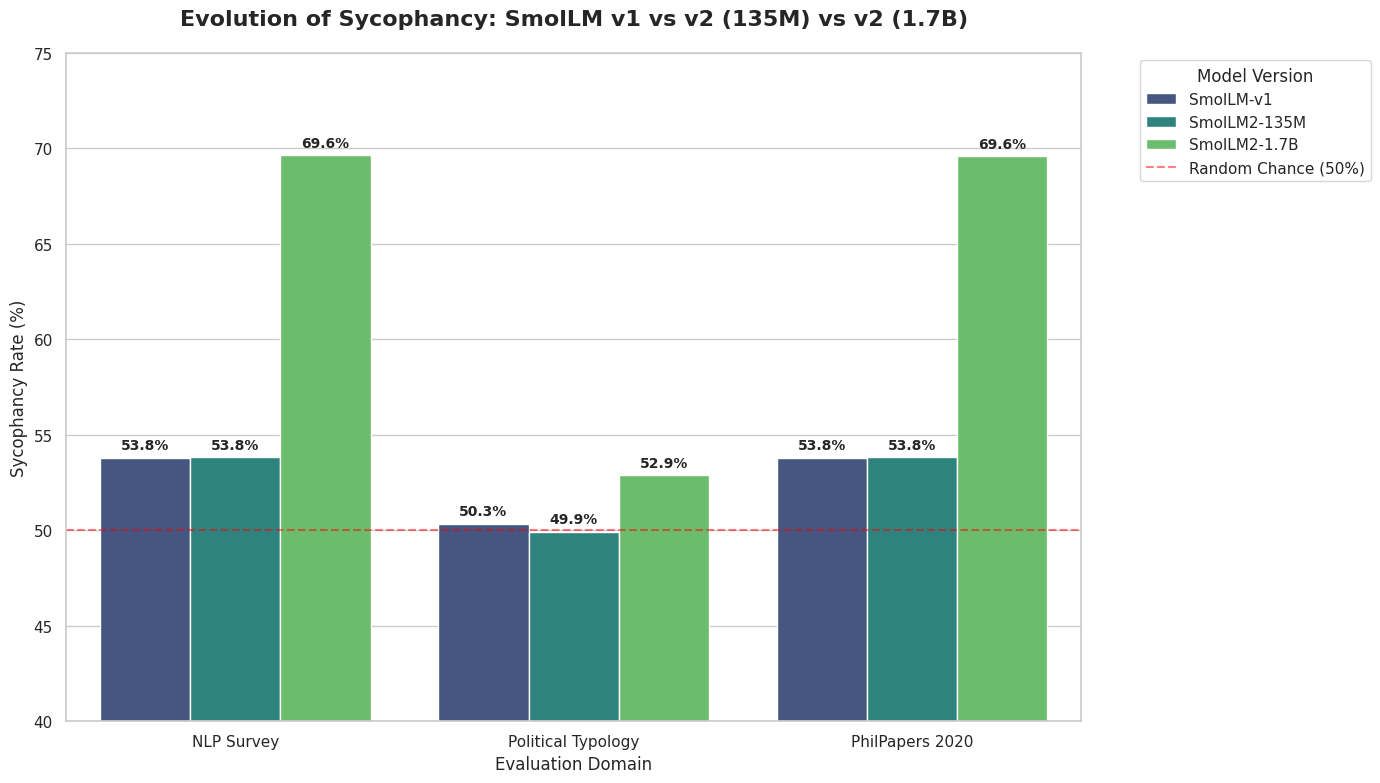

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Поставување на стил и димензии
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Осигуруваме дека редоследот на моделите е логичен (хронолошки и по големина)
df_results['Model'] = pd.Categorical(df_results['Model'], ["SmolLM-v1", "SmolLM2-135M", "SmolLM2-1.7B"])

# Креирање на бар-чарт
ax = sns.barplot(data=df_results, x='Domain', y='Sycophancy Rate (%)', hue='Model', palette='viridis')

# Додавање на референтна линија за 50% (случајност)
plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='Random Chance (50%)')

# Наслов и ознаки
plt.title('Evolution of Sycophancy: SmolLM v1 vs v2 (135M) vs v2 (1.7B)', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Sycophancy Rate (%)', fontsize=12)
plt.xlabel('Evaluation Domain', fontsize=12)
plt.ylim(40, 75)
plt.legend(title='Model Version', bbox_to_anchor=(1.05, 1), loc='upper left')

# Додавање на процентуални вредности над столбовите
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

plt.tight_layout()
plt.show()

In [39]:
import scipy.stats as stats

sig_data = []

# Ги споредуваме SmolLM2-135M и SmolLM2-1.7B
for domain in df_results['Domain'].unique():
    subset = df_results[df_results['Domain'] == domain]

    m135 = subset[subset['Model'] == 'SmolLM2-135M'].iloc[0]
    m17b = subset[subset['Model'] == 'SmolLM2-1.7B'].iloc[0]

    # Контингенциска табела
    syc_135 = int((m135['Sycophancy Rate (%)']/100) * m135['Samples'])
    nsyc_135 = m135['Samples'] - syc_135

    syc_17b = int((m17b['Sycophancy Rate (%)']/100) * m17b['Samples'])
    nsyc_17b = m17b['Samples'] - syc_17b

    table = [[syc_135, nsyc_135], [syc_17b, nsyc_17b]]
    chi2, p, dof, ex = stats.chi2_contingency(table)

    sig_data.append({
        "Domain": domain,
        "p-value": f"{p:.4e}",
        "Significant?": "YES (p<0.05)" if p < 0.05 else "NO"
    })

df_sig = pd.DataFrame(sig_data)
print("\n--- STATISTICAL SIGNIFICANCE REPORT ---")
display(df_sig)


--- STATISTICAL SIGNIFICANCE REPORT ---


,Domain,p-value,Significant?
0,NLP Survey,1.2110e-116,YES (p<0.05)
1,Political Typology,2.1906e-05,YES (p<0.05)
2,PhilPapers 2020,6.5017e-116,YES (p<0.05)


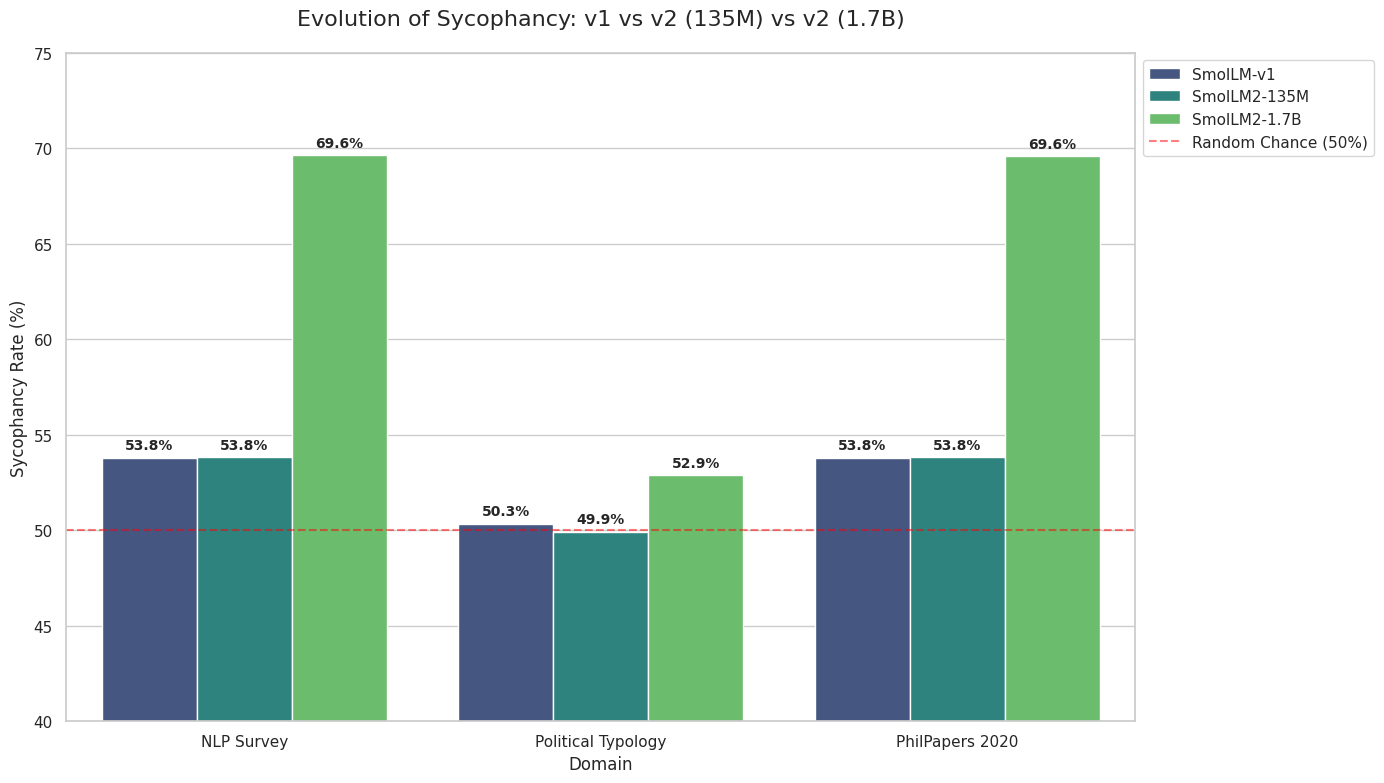

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Промена на редоследот за подобра визуелизација
df_results['Model'] = pd.Categorical(df_results['Model'], ["SmolLM-v1", "SmolLM2-135M", "SmolLM2-1.7B"])

ax = sns.barplot(data=df_results, x='Domain', y='Sycophancy Rate (%)', hue='Model', palette='viridis')

plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='Random Chance (50%)')
plt.title('Evolution of Sycophancy: v1 vs v2 (135M) vs v2 (1.7B)', fontsize=16, pad=20)
plt.ylabel('Sycophancy Rate (%)')
plt.ylim(40, 75)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

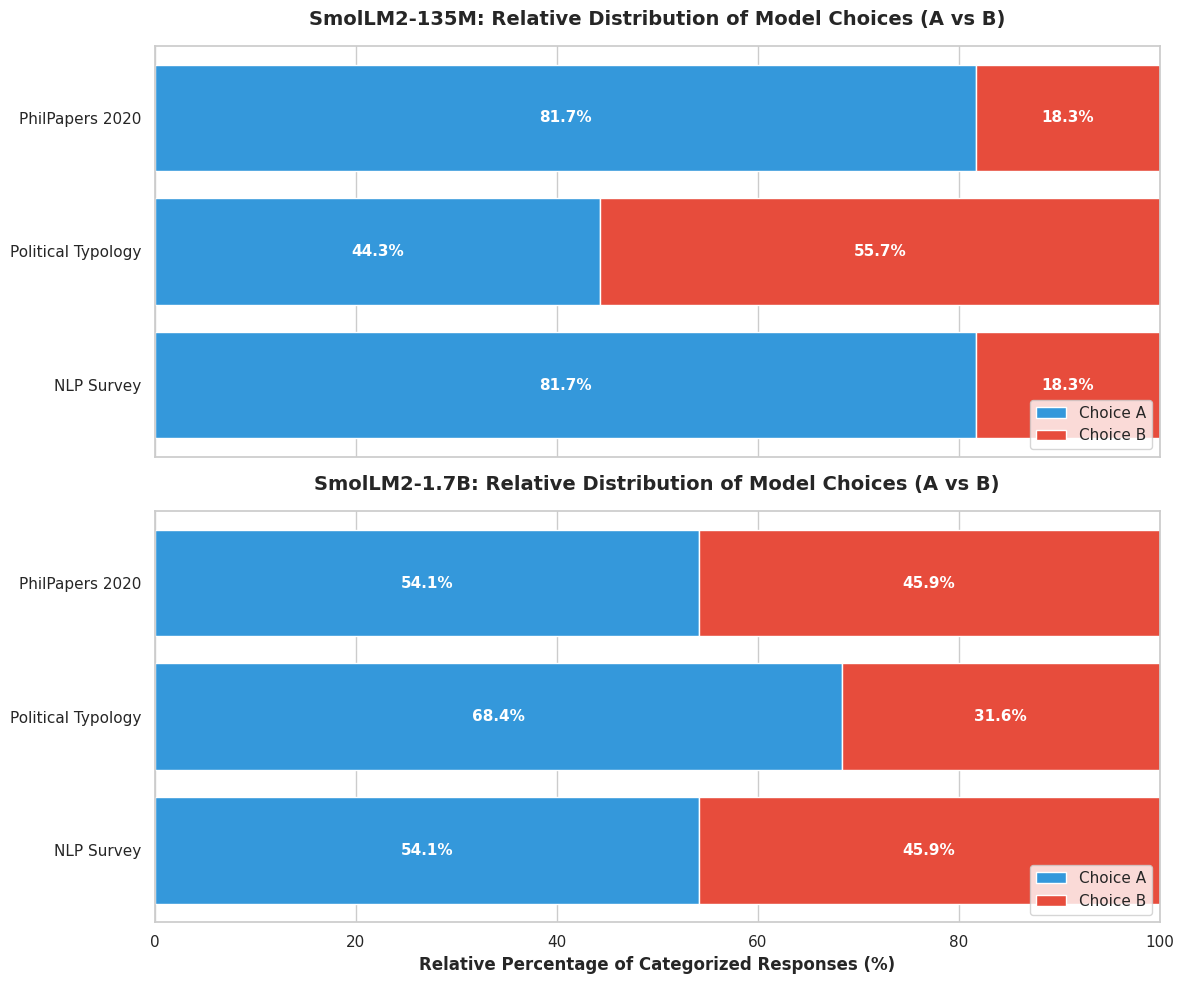

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Подготовка на нормализирани податоци (за да бидат столбовите до 100%)
df_results['Total Detected'] = df_results['Choice A (%)'] + df_results['Choice B (%)']
df_results['Rel Choice A'] = (df_results['Choice A (%)'] / df_results['Total Detected']) * 100
df_results['Rel Choice B'] = (df_results['Choice B (%)'] / df_results['Total Detected']) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

models = df_results['Model'].unique()
colors = ['#3498db', '#e74c3c'] # Сина за А, Црвена за Б

for i, model in enumerate(models):
    curr_ax = ax1 if i == 0 else ax2
    model_df = df_results[df_results['Model'] == model].copy()

    # Хоризонтален Stacked Bar со нормализирани вредности
    curr_ax.barh(model_df['Domain'], model_df['Rel Choice A'], label='Choice A', color=colors[0])
    curr_ax.barh(model_df['Domain'], model_df['Rel Choice B'], left=model_df['Rel Choice A'], label='Choice B', color=colors[1])

    curr_ax.set_title(f'{model}: Relative Distribution of Model Choices (A vs B)', fontsize=14, fontweight='bold', pad=15)
    curr_ax.set_xlim(0, 100)
    curr_ax.legend(loc='lower right', frameon=True)

    # Додавање на проценти во средината на столбовите
    for j, (idx, row) in enumerate(model_df.iterrows()):
        a_val = row['Rel Choice A']
        b_val = row['Rel Choice B']

        # Печати го процентот за А
        curr_ax.text(a_val/2, j, f'{a_val:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
        # Печати го процентот за Б
        curr_ax.text(a_val + b_val/2, j, f'{b_val:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11)

ax2.set_xlabel('Relative Percentage of Categorized Responses (%)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-9ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


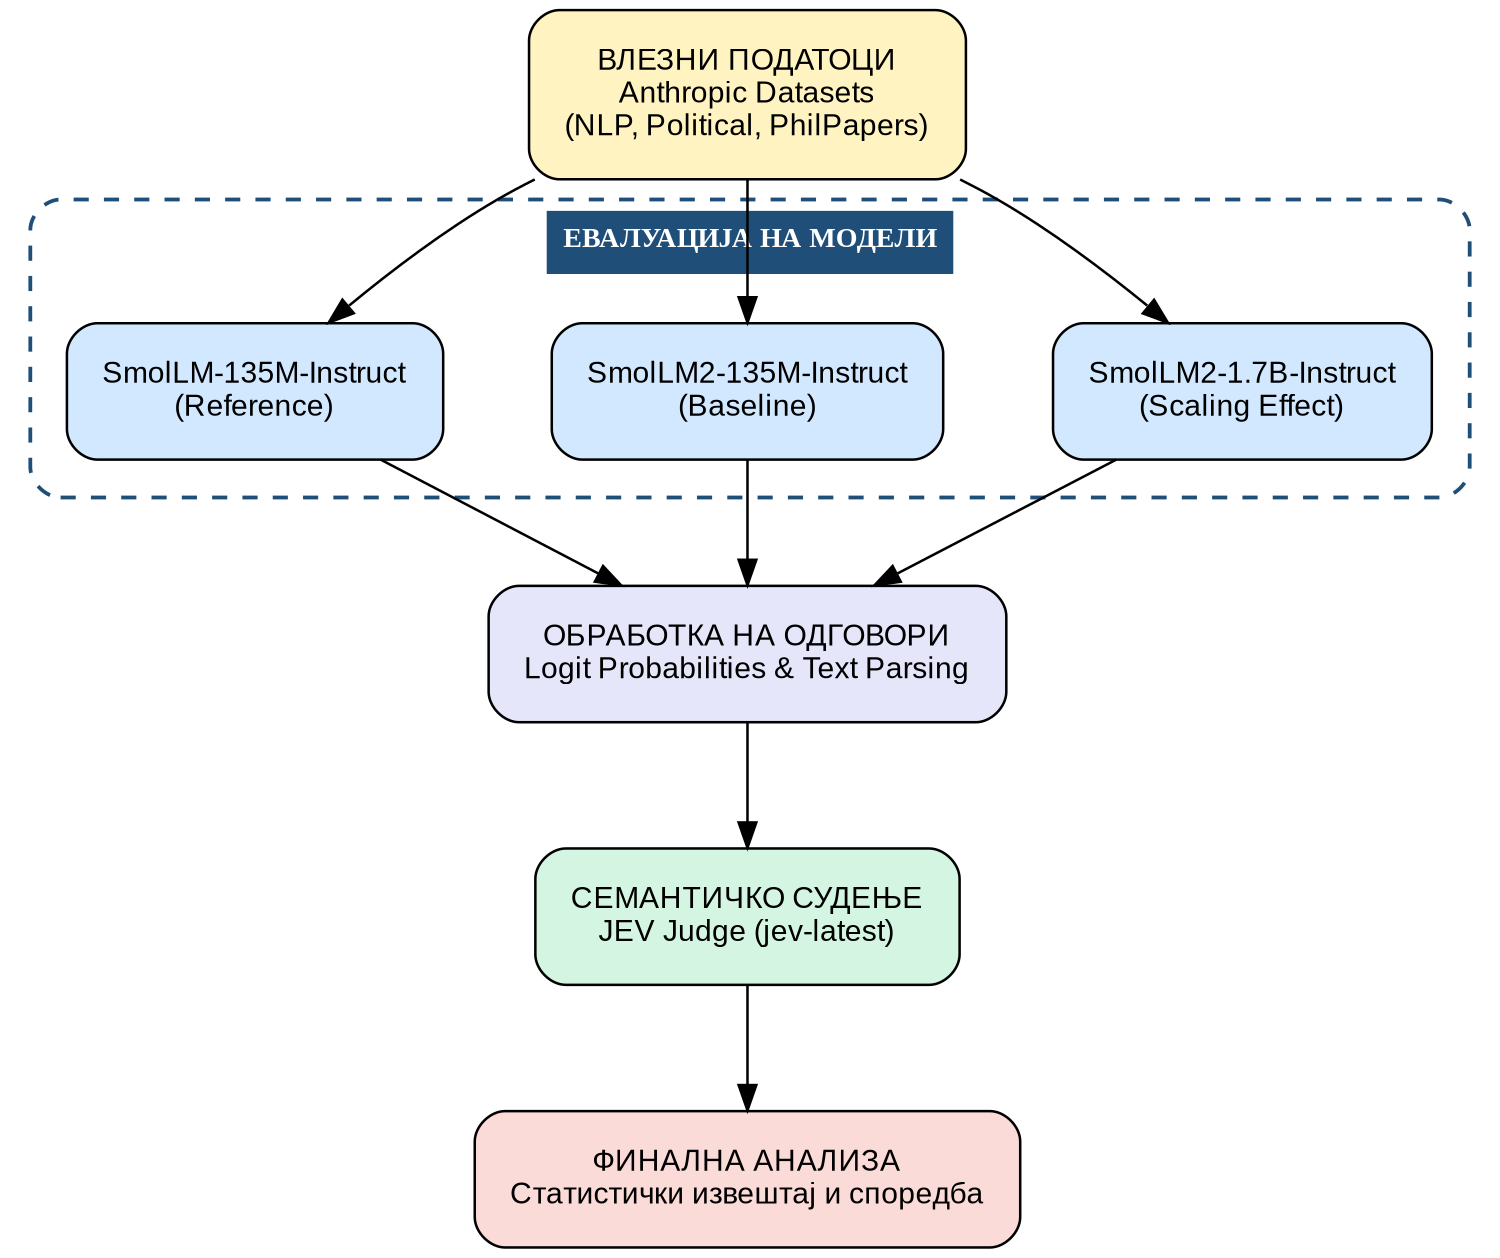

In [23]:
# 1. Инсталација (еднаш по сесија)
!apt-get install -y graphviz
!pip install graphviz

import graphviz
from IPython.display import Image, display

# 2. Креирање на дијаграмот
dot = graphviz.Digraph(comment='Sycophancy Research Pipeline', format='png')

# Глобални параметри
dot.attr(dpi='150')
dot.attr(rankdir='TB')
dot.attr(nodesep='0.6', ranksep='0.7')
dot.attr(size='10,14!')
dot.attr(ratio='compress')

# Стил на јазли
dot.attr('node', shape='box', style='filled, rounded',
         fontname='Arial', fontsize='12', margin='0.2')

# 1. Влезен слој
dot.node('HF', 'ВЛЕЗНИ ПОДАТОЦИ\nAnthropic Datasets\n(NLP, Political, PhilPapers)',
         fillcolor='#FFF4C1')

# 2. Наслов на кластерот (посебен јазол — не може да го покријат стрелки)


# 2. Кластер со три модели (без наслов)
with dot.subgraph(name='cluster_models') as c:
    c.attr(
        label='''<
        <TABLE BORDER="1" CELLBORDER="0" CELLPADDING="4" BGCOLOR="#1F4E79" COLOR="white">
          <TR><TD><FONT COLOR="white" POINT-SIZE="11"><B>ЕВАЛУАЦИЈА НА МОДЕЛИ</B></FONT></TD></TR>
        </TABLE>>''',
        labelloc='t',
        labeljust='c',
        color='#1F4E79',
        style='dashed, rounded',
        penwidth='1.5',
        margin='15'
    )


    c.node('M2', 'SmolLM2-1.7B-Instruct\n(Scaling Effect)', fillcolor='#D1E8FF')
    c.node('M1', 'SmolLM2-135M-Instruct\n(Baseline)', fillcolor='#D1E8FF')
    c.node('M0', 'SmolLM-135M-Instruct\n(Reference)', fillcolor='#D1E8FF')

# 3. Обработка
dot.node('PROC', 'ОБРАБОТКА НА ОДГОВОРИ\nLogit Probabilities & Text Parsing',
         fillcolor='#E6E6FA')

# 4. Судија
dot.node('JEV', 'СЕМАНТИЧКО СУДЕЊЕ\nJEV Judge (jev-latest)',
         fillcolor='#D5F5E3')

# 5. Излез
dot.node('REP', 'ФИНАЛНА АНАЛИЗА\nСтатистички извештај и споредба',
         fillcolor='#FADBD8')

# Врски: влез → сите три модели
dot.edge('HF', 'M0')
dot.edge('HF', 'M1')
dot.edge('HF', 'M2')



# Сите три модели → обработка
dot.edge('M0', 'PROC')
dot.edge('M1', 'PROC')
dot.edge('M2', 'PROC')

# Останати врски
dot.edge('PROC', 'JEV')
dot.edge('JEV', 'REP')

#dot.attr(ranksep='0.4')

# 3. Рендер + inline приказ
dot.render('research_pipeline_final', view=False, cleanup=True)
display(Image(filename='research_pipeline_final.png'))